# **Springboard Decision Tree Specialty Coffee Case Study - Tier 3**




# The Scenario

Imagine you've just finished the Springboard Data Science Career Track course, and have been hired by a rising popular specialty coffee company - RR Diner Coffee - as a data scientist. Congratulations!

RR Diner Coffee sells two types of thing:
- specialty coffee beans, in bulk (by the kilogram only) 
- coffee equipment and merchandise (grinders, brewing equipment, mugs, books, t-shirts).

RR Diner Coffee has three stores, two in Europe and one in the USA. The flagshap store is in the USA, and everything is quality assessed there, before being shipped out. Customers further away from the USA flagship store have higher shipping charges. 

You've been taken on at RR Diner Coffee because the company are turning towards using data science and machine learning to systematically make decisions about which coffee farmers they should strike deals with. 

RR Diner Coffee typically buys coffee from farmers, processes it on site, brings it back to the USA, roasts it, packages it, markets it, and ships it (only in bulk, and after quality assurance) to customers internationally. These customers all own coffee shops in major cities like New York, Paris, London, Hong Kong, Tokyo, and Berlin. 

Now, RR Diner Coffee has a decision about whether to strike a deal with a legendary coffee farm (known as the **Hidden Farm**) in rural China: there are rumours their coffee tastes of lychee and dark chocolate, while also being as sweet as apple juice. 

It's a risky decision, as the deal will be expensive, and the coffee might not be bought by customers. The stakes are high: times are tough, stocks are low, farmers are reverting to old deals with the larger enterprises and the publicity of selling *Hidden Farm* coffee could save the RR Diner Coffee business. 

Your first job, then, is ***to build a decision tree to predict how many units of the Hidden Farm Chinese coffee will be purchased by RR Diner Coffee's most loyal customers.*** 

To this end, you and your team have conducted a survey of 710 of the most loyal RR Diner Coffee customers, collecting data on the customers':
- age
- gender 
- salary 
- whether they have bought at least one RR Diner Coffee product online
- their distance from the flagship store in the USA (standardized to a number between 0 and 11) 
- how much they spent on RR Diner Coffee products on the week of the survey 
- how much they spent on RR Diner Coffee products in the month preeding the survey
- the number of RR Diner coffee bean shipments each customer has ordered over the preceding year. 

You also asked each customer participating in the survey whether they would buy the Hidden Farm coffee, and some (but not all) of the customers gave responses to that question. 

You sit back and think: if more than 70% of the interviewed customers are likely to buy the Hidden Farm coffee, you will strike the deal with the local Hidden Farm farmers and sell the coffee. Otherwise, you won't strike the deal and the Hidden Farm coffee will remain in legends only. There's some doubt in your mind about whether 70% is a reasonable threshold, but it'll do for the moment. 

To solve the problem, then, you will build a decision tree to implement a classification solution. 


-------------------------------
As ever, this notebook is **tiered**, meaning you can elect that tier that is right for your confidence and skill level. There are 3 tiers, with tier 1 being the easiest and tier 3 being the hardest. This is ***tier 3***, so it will be challenging. 

**1. Sourcing and loading** 
- Import packages
- Load data
- Explore the data

 
**2. Cleaning, transforming and visualizing**
- Cleaning the data
- Train/test split
  
  
**3. Modelling** 
- Model 1: Entropy model - no max_depth
- Model 2: Gini impurity model - no max_depth
- Model 3: Entropy model - max depth 3
- Model 4: Gini impurity model - max depth 3


**4. Evaluating and concluding** 
- How many customers will buy Hidden Farm coffee?
- Decision

**5. Random Forest** 
- Import necessary modules
- Model
- Revise conclusion
    

## Solution scope and reproducibility
All Tier 3 exercises are completed below. The supplied CSV has **702 rows**, not the scenario's 710. There are **474 labeled customers and 228 unlabeled customers**; no feature values are missing and no exact duplicate rows occur. Missing targets are reserved for prediction, never imputed as labels.

We retain the assignment's 25% test fraction and split seed 246, adding stratification. One-hot encoding is fitted on training data only, and within each CV fold through a pipeline. Four required trees use seed 1234. A small training-only grid tunes the forest. Results may differ from the template's unstratified example. No Graphviz installation is required; full trees are drawn with `plot_tree`.

# 0. Overview

This notebook uses decision trees to determine whether the factors of salary, gender, age, how much money the customer spent last week and during the preceding month on RR Diner Coffee products, how many kilogram coffee bags the customer bought over the last year, whether they have bought at least one RR Diner Coffee product online, and their distance from the flagship store in the USA, could predict whether customers would purchase the Hidden Farm coffee if a deal with its farmers were struck. 

# 1. Sourcing and loading
## 1a. Import Packages

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import tree, metrics
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

## 1b. Load data 

In [2]:
coffeeData = pd.read_csv('RRDinerCoffeeData.csv')
raw_data = coffeeData.copy()

## 1c. Explore the data

As we've seen, exploration entails doing things like checking out the **initial appearance** of the data with head(), the **dimensions** of our data with .shape, the **data types** of the variables with .info(), the **number of non-null values**, how much **memory** is being used to store the data, and finally the major summary statistcs capturing **central tendancy, dispersion and the null-excluding shape of the dataset's distribution**. 

How much of this can you do yourself by this point in the course? Have a real go. 

In [3]:
coffeeData.head()

,Age,Gender,num_coffeeBags_per_year,spent_week,spent_month,SlrAY,Distance,Online,Decision
0,36,Female,0,24,73,42789,0.003168,0,1.0
1,24,Male,0,44,164,74035,0.520906,0,NaN
2,24,Male,0,39,119,30563,0.916005,1,1.0
3,20,Male,0,30,107,13166,0.932098,1,NaN
4,24,Female,0,20,36,14244,0.965881,0,1.0


In [4]:
coffeeData.shape

(702, 9)

In [5]:
coffeeData.info()
print('Missing values:\n', coffeeData.isna().sum())
print('Duplicate rows:', coffeeData.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 702 entries, 0 to 701
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      702 non-null    int64  
 1   Gender                   702 non-null    str    
 2   num_coffeeBags_per_year  702 non-null    int64  
 3   spent_week               702 non-null    int64  
 4   spent_month              702 non-null    int64  
 5   SlrAY                    702 non-null    int64  
 6   Distance                 702 non-null    float64
 7   Online                   702 non-null    int64  
 8   Decision                 474 non-null    float64
dtypes: float64(2), int64(6), str(1)
memory usage: 52.9 KB
Missing values:
 Age                          0
Gender                       0
num_coffeeBags_per_year      0
spent_week                   0
spent_month                  0
SlrAY                        0
Distance                     0
Online              

In [6]:
coffeeData.describe(include='all')

,Age,Gender,num_coffeeBags_per_year,spent_week,spent_month,SlrAY,Distance,Online,Decision
count,702.000000,702,702.000000,702.000000,702.000000,702.000000,702.000000,702.000000,474.000000
unique,NaN,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,355,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,34.243590,NaN,2.710826,32.853276,107.923077,43819.843305,4.559186,0.531339,0.639241
std,13.927945,NaN,1.593629,15.731878,55.348485,26192.626943,3.116275,0.499373,0.480728
min,16.000000,NaN,0.000000,0.000000,0.000000,1617.000000,0.003168,0.000000,0.000000
25%,23.000000,NaN,1.000000,24.250000,62.000000,22812.250000,1.877812,0.000000,0.000000
50%,28.000000,NaN,3.000000,36.000000,113.500000,41975.000000,4.196167,1.000000,1.000000
75%,46.000000,NaN,4.000000,43.000000,150.750000,60223.000000,6.712022,1.000000,1.000000


# 2. Cleaning, transforming and visualizing
## 2a. Cleaning the data

Some datasets don't require any cleaning, but almost all do. This one does. We need to replace '1.0' and '0.0' in the 'Decision' column by 'YES' and 'NO' respectively, clean up the values of the 'gender' column, and change the column names to words which maximize meaning and clarity. 

First, let's change the name of `spent_week`, `spent_month`, and `SlrAY` to `spent_last_week` and `spent_last_month` and `salary` respectively.

In [7]:
coffeeData.columns.tolist()

['Age',
 'Gender',
 'num_coffeeBags_per_year',
 'spent_week',
 'spent_month',
 'SlrAY',
 'Distance',
 'Online',
 'Decision']

In [8]:
coffeeData = coffeeData.rename(columns={'spent_week': 'spent_last_week', 'spent_month': 'spent_last_month', 'SlrAY': 'salary', 'Age': 'age', 'Gender': 'gender', 'Distance': 'distance', 'Online': 'online'})

In [9]:
coffeeData.columns.tolist()

['age',
 'gender',
 'num_coffeeBags_per_year',
 'spent_last_week',
 'spent_last_month',
 'salary',
 'distance',
 'online',
 'Decision']

In [10]:
coffeeData['gender'].value_counts(dropna=False)

gender
Male      355
Female    340
female      1
F           1
f           1
FEMALE      1
MALE        1
male        1
M           1
Name: count, dtype: int64

In [11]:
coffeeData['gender'].unique()

<ArrowStringArray>
['Female', 'Male', 'female', 'F', 'f ', 'FEMALE', 'MALE', 'male', 'M']
Length: 9, dtype: str

We can see a bunch of inconsistency here.

Use replace() to make the values of the `gender` column just `Female` and `Male`.

In [12]:
coffeeData['gender'] = coffeeData['gender'].str.strip().str.lower()
coffeeData['gender'] = coffeeData['gender'].replace({'female': 'Female', 'f': 'Female'})

In [13]:
coffeeData['gender'].unique()

<ArrowStringArray>
['Female', 'male', 'm']
Length: 3, dtype: str

In [14]:
coffeeData['gender'] = coffeeData['gender'].replace({'male': 'Male', 'm': 'Male'})

In [15]:
assert set(coffeeData['gender'].unique()) == {'Female', 'Male'}
coffeeData['gender'].unique()

<ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str

In [16]:
coffeeData['Decision'].unique()

array([ 1., nan,  0.])

We now want to replace `1.0` and `0.0` in the `Decision` column by `YES` and `NO` respectively.

In [17]:
assert set(coffeeData['Decision'].dropna().unique()) == {0.0, 1.0}
coffeeData['Decision'] = coffeeData['Decision'].map({1.0: 'YES', 0.0: 'NO'})

In [18]:
coffeeData['Decision'].value_counts(dropna=False)

Decision
YES    303
NaN    228
NO     171
Name: count, dtype: int64

## 2b. Train/test split
To execute the train/test split properly, we need to do five things: 
1. Drop all rows with a null value in the `Decision` column, and save the result as NOPrediction: a dataset that will contain all known values for the decision 
2. Visualize the data using scatter and boxplots of several variables in the y-axis and the decision on the x-axis
3. Get the subset of coffeeData with null values in the `Decision` column, and save that subset as Prediction
4. Divide the NOPrediction subset into X and y, and then further divide those subsets into train and test subsets for X and y respectively
5. Create dummy variables to deal with categorical inputs

### 1. Drop all null values within the `Decision` column, and save the result as NoPrediction

In [19]:
NOPrediction = coffeeData.dropna(subset=['Decision']).copy()
print(NOPrediction['Decision'].describe())
assert NOPrediction.drop(columns='Decision').isna().sum().sum() == 0

count     474
unique      2
top       YES
freq      303
Name: Decision, dtype: object


### 2. Visualize the data using scatter and boxplots of several variables in the y-axis and the decision on the x-axis

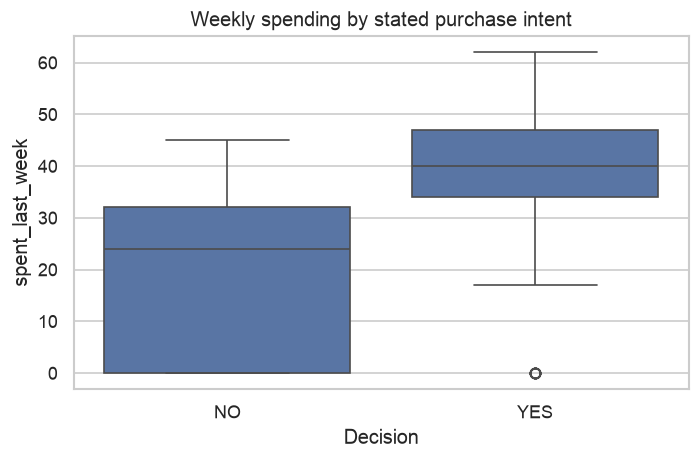

          count  median       mean
Decision                          
NO          171    24.0  20.678363
YES         303    40.0  39.316832


In [20]:
fig, ax = plt.subplots(figsize=(6,4))
sns.boxplot(data=NOPrediction, x='Decision', y='spent_last_week', order=['NO','YES'], ax=ax)
ax.set_title('Weekly spending by stated purchase intent')
plt.tight_layout()
plt.show()
print(NOPrediction.groupby('Decision')['spent_last_week'].agg(['count','median','mean']))

**Interpretation:** Compare the medians and spread printed above. Spending can be associated with stated purchase intent, but overlap means spending alone does not determine every decision. This observational plot does not establish a causal effect. It is exploratory; predictive performance must be checked on held-out data.

The median weekly spending is shown in the output above. The YES and NO distributions are not perfectly separated; this motivates using multiple predictors.

**Observed pattern:** YES respondents have median weekly spending of **40**, compared with **24** for NO respondents (means 39.32 versus 20.68). Higher weekly spending is associated with willingness to buy in this sample, although ranges overlap and there are zero-spending YES outliers.

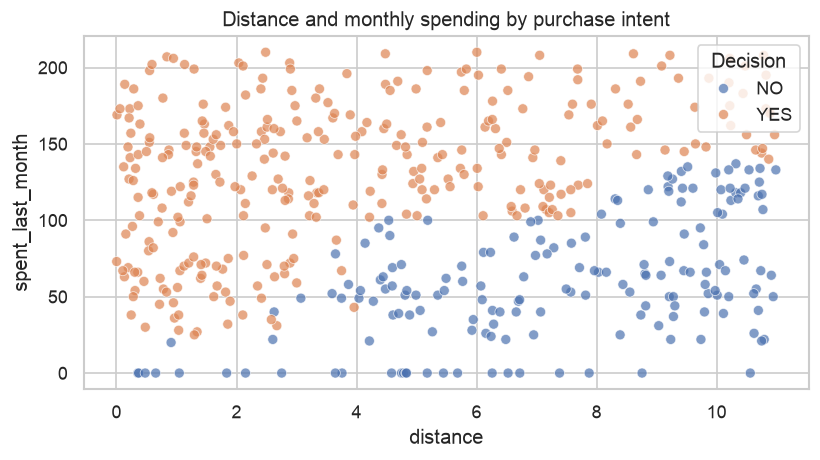

In [21]:
fig, ax = plt.subplots(figsize=(7,4))
sns.scatterplot(data=NOPrediction, x='distance', y='spent_last_month', hue='Decision', hue_order=['NO','YES'], alpha=0.7, ax=ax)
ax.set_title('Distance and monthly spending by purchase intent')
plt.tight_layout()
plt.show()

**Interpretation:** The scatterplot shows the joint distribution of distance and monthly spending and whether groups overlap. It suggests candidate split features, but does not prove a decision boundary, causation, or performance on unseen customers. Distance is a standardized measure, not miles. The eight supplied predictors are retained as specified rather than selecting features from this full-data plot.

**Observed pattern:** Higher monthly spending is predominantly associated with YES. Among lower spenders, customers closer to the flagship often say YES while those farther away often say NO; the combination of distance and spending therefore looks useful for tree splits. Some observations overlap, so we rely on evaluation rather than visual separation alone.

### 3. Get the subset of coffeeData with null values in the Decision column, and save that subset as Prediction

In [22]:
Prediction = coffeeData.loc[coffeeData['Decision'].isna()].copy()
print('Known decisions:', len(NOPrediction), '| Unknown:', len(Prediction))
assert len(NOPrediction) + len(Prediction) == len(coffeeData)

Known decisions: 474 | Unknown: 228


In [23]:
Prediction.describe(include='all')

,age,gender,num_coffeeBags_per_year,spent_last_week,spent_last_month,salary,distance,online,Decision
count,228.000000,228,228.000000,228.000000,228.000000,228.000000,228.000000,228.000000,0
unique,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,0
top,NaN,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,125,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,31.802632,NaN,2.960526,33.394737,110.407895,41923.741228,3.428836,0.570175,NaN
std,14.302293,NaN,1.585514,15.697930,53.786536,27406.768360,2.153102,0.496140,NaN
min,16.000000,NaN,0.000000,0.000000,0.000000,1617.000000,0.010048,0.000000,NaN
25%,22.000000,NaN,2.000000,25.750000,65.000000,15911.500000,1.699408,0.000000,NaN
50%,25.000000,NaN,3.000000,37.000000,113.500000,40987.500000,3.208673,1.000000,NaN
75%,39.000000,NaN,4.000000,44.000000,151.250000,58537.000000,5.261184,1.000000,NaN


### 4. Divide the NOPrediction subset into X and y

In [24]:
NOPrediction.columns.tolist()

['age',
 'gender',
 'num_coffeeBags_per_year',
 'spent_last_week',
 'spent_last_month',
 'salary',
 'distance',
 'online',
 'Decision']

In [25]:
features = [c for c in coffeeData.columns if c != 'Decision']
X = NOPrediction[features].copy()
y = NOPrediction['Decision'].copy()

### 5. One-hot encoding without leakage
Define an encoder here, then fit it only after splitting. `handle_unknown='ignore'` gives compatible columns for unseen categories. Numeric predictors stay numeric; gender is one-hot encoded. This improves on the template's suggestion to encode the full dataset first. No scaling is necessary for these tree models.

In [26]:
preprocessor = ColumnTransformer([('gender', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ['gender'])], remainder='passthrough', verbose_feature_names_out=False)

### 6. Further divide those subsets into train and test subsets for X and y respectively: X_train, X_test, y_train, y_test

In [27]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=246, stratify=y)
encoder = clone(preprocessor)
X_train = encoder.fit_transform(X_train_raw)
X_test = encoder.transform(X_test_raw)
feature_names = encoder.get_feature_names_out().tolist()
print('Training / test:', X_train.shape, X_test.shape)
print(pd.DataFrame({'train_fraction':y_train.value_counts(normalize=True),
                    'test_fraction':y_test.value_counts(normalize=True)}))
assert set(X_train_raw.index).isdisjoint(X_test_raw.index)
assert set(Prediction.index).isdisjoint(X.index)

# Define all candidate trees before evaluating on the test set.
tree_candidates = {
    'Entropy unlimited': tree.DecisionTreeClassifier(criterion='entropy', random_state=1234),
    'Gini unlimited': tree.DecisionTreeClassifier(criterion='gini', random_state=1234),
    'Entropy depth 3': tree.DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=1234),
    'Gini depth 3': tree.DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=1234)}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=246)
cv_rows = []
for name, estimator in tree_candidates.items():
    pipe = Pipeline([('preprocess', clone(preprocessor)), ('model', clone(estimator))])
    scores = cross_validate(pipe, X_train_raw, y_train, cv=cv,
                            scoring=['accuracy','balanced_accuracy'])
    cv_rows.append({'model':name, 'cv_accuracy':scores['test_accuracy'].mean(),
                    'cv_balanced_accuracy':scores['test_balanced_accuracy'].mean(),
                    'cv_balanced_std':scores['test_balanced_accuracy'].std()})
cv_table = pd.DataFrame(cv_rows).set_index('model')
selected_tree_name = cv_table['cv_balanced_accuracy'].idxmax()
print(cv_table.round(4))
print('Tree selected using training CV only:', selected_tree_name)
evaluation_rows = []
def evaluate(name, model):
    pred = model.predict(X_test)
    yes_index = list(model.classes_).index('YES')
    row = dict(model=name, train_accuracy=model.score(X_train,y_train),
        test_accuracy=metrics.accuracy_score(y_test,pred),
        balanced_accuracy=metrics.balanced_accuracy_score(y_test,pred),
        precision_yes=metrics.precision_score(y_test,pred,pos_label='YES',zero_division=0),
        recall_yes=metrics.recall_score(y_test,pred,pos_label='YES',zero_division=0),
        f1_yes=metrics.f1_score(y_test,pred,pos_label='YES',zero_division=0),
        roc_auc=metrics.roc_auc_score((y_test=='YES').astype(int),model.predict_proba(X_test)[:,yes_index]))
    evaluation_rows.append(row)
    print(pd.Series(row).to_string())
    print(metrics.classification_report(y_test,pred,labels=['NO','YES'],digits=4,zero_division=0))
    print('Confusion matrix: actual rows / predicted columns, NO then YES')
    print(metrics.confusion_matrix(y_test,pred,labels=['NO','YES']))
def show_tree(model, name):
    fig, ax = plt.subplots(figsize=(22,9))
    tree.plot_tree(model, feature_names=feature_names, class_names=model.classes_,
                   filled=True, rounded=True, fontsize=7, ax=ax)
    ax.set_title(name)
    plt.tight_layout()
    plt.show()

Training / test: (355, 9) (119, 9)
          train_fraction  test_fraction
Decision                               
YES             0.639437       0.638655
NO              0.360563       0.361345
                   cv_accuracy  cv_balanced_accuracy  cv_balanced_std
model                                                                
Entropy unlimited       0.9831                0.9784           0.0129
Gini unlimited          0.9803                0.9747           0.0283
Entropy depth 3         0.9437                0.9373           0.0238
Gini depth 3            0.9803                0.9763           0.0254
Tree selected using training CV only: Entropy unlimited


# 3. Modelling
It's useful to look at the scikit-learn documentation on decision trees https://scikit-learn.org/stable/modules/tree.html before launching into applying them. If you haven't seen them before, take a look at that link, in particular the section `1.10.5.` 

## Model 1: Entropy model - no max_depth

We'll give you a little more guidance here, as the Python is hard to deduce, and scikitlearn takes some getting used to.

Theoretically, let's remind ourselves of what's going on with a decision tree implementing an entropy model.

Ross Quinlan's **ID3 Algorithm** was one of the first, and one of the most basic, to use entropy as a metric.

**Entropy** is a measure of how uncertain we are about which category the data-points fall into at a given point in the tree. The **Information gain** of a specific feature with a threshold (such as 'spent_last_month <= 138.0') is the difference in entropy that exists before and after splitting on that feature; i.e., the information we gain about the categories of the data-points by splitting on that feature and that threshold. 

Naturally, we want to minimize entropy and maximize information gain. Quinlan's ID3 algorithm is designed to output a tree such that the features at each node, starting from the root, and going all the way down to the leaves, have maximial information gain. We want a tree whose leaves have elements that are *homogeneous*, that is, all of the same category. 

The first model will be the hardest. Persevere and you'll reap the rewards: you can use almost exactly the same code for the other models. 

In [28]:
entr_model = clone(tree_candidates['Entropy unlimited'])
entr_model.fit(X_train, y_train)
y_pred = entr_model.predict(X_test)
print(pd.Series(y_pred).value_counts())
print('Depth:', entr_model.get_depth(), '| Leaves:', entr_model.get_n_leaves())

YES    76
NO     43
Name: count, dtype: int64
Depth: 6 | Leaves: 11


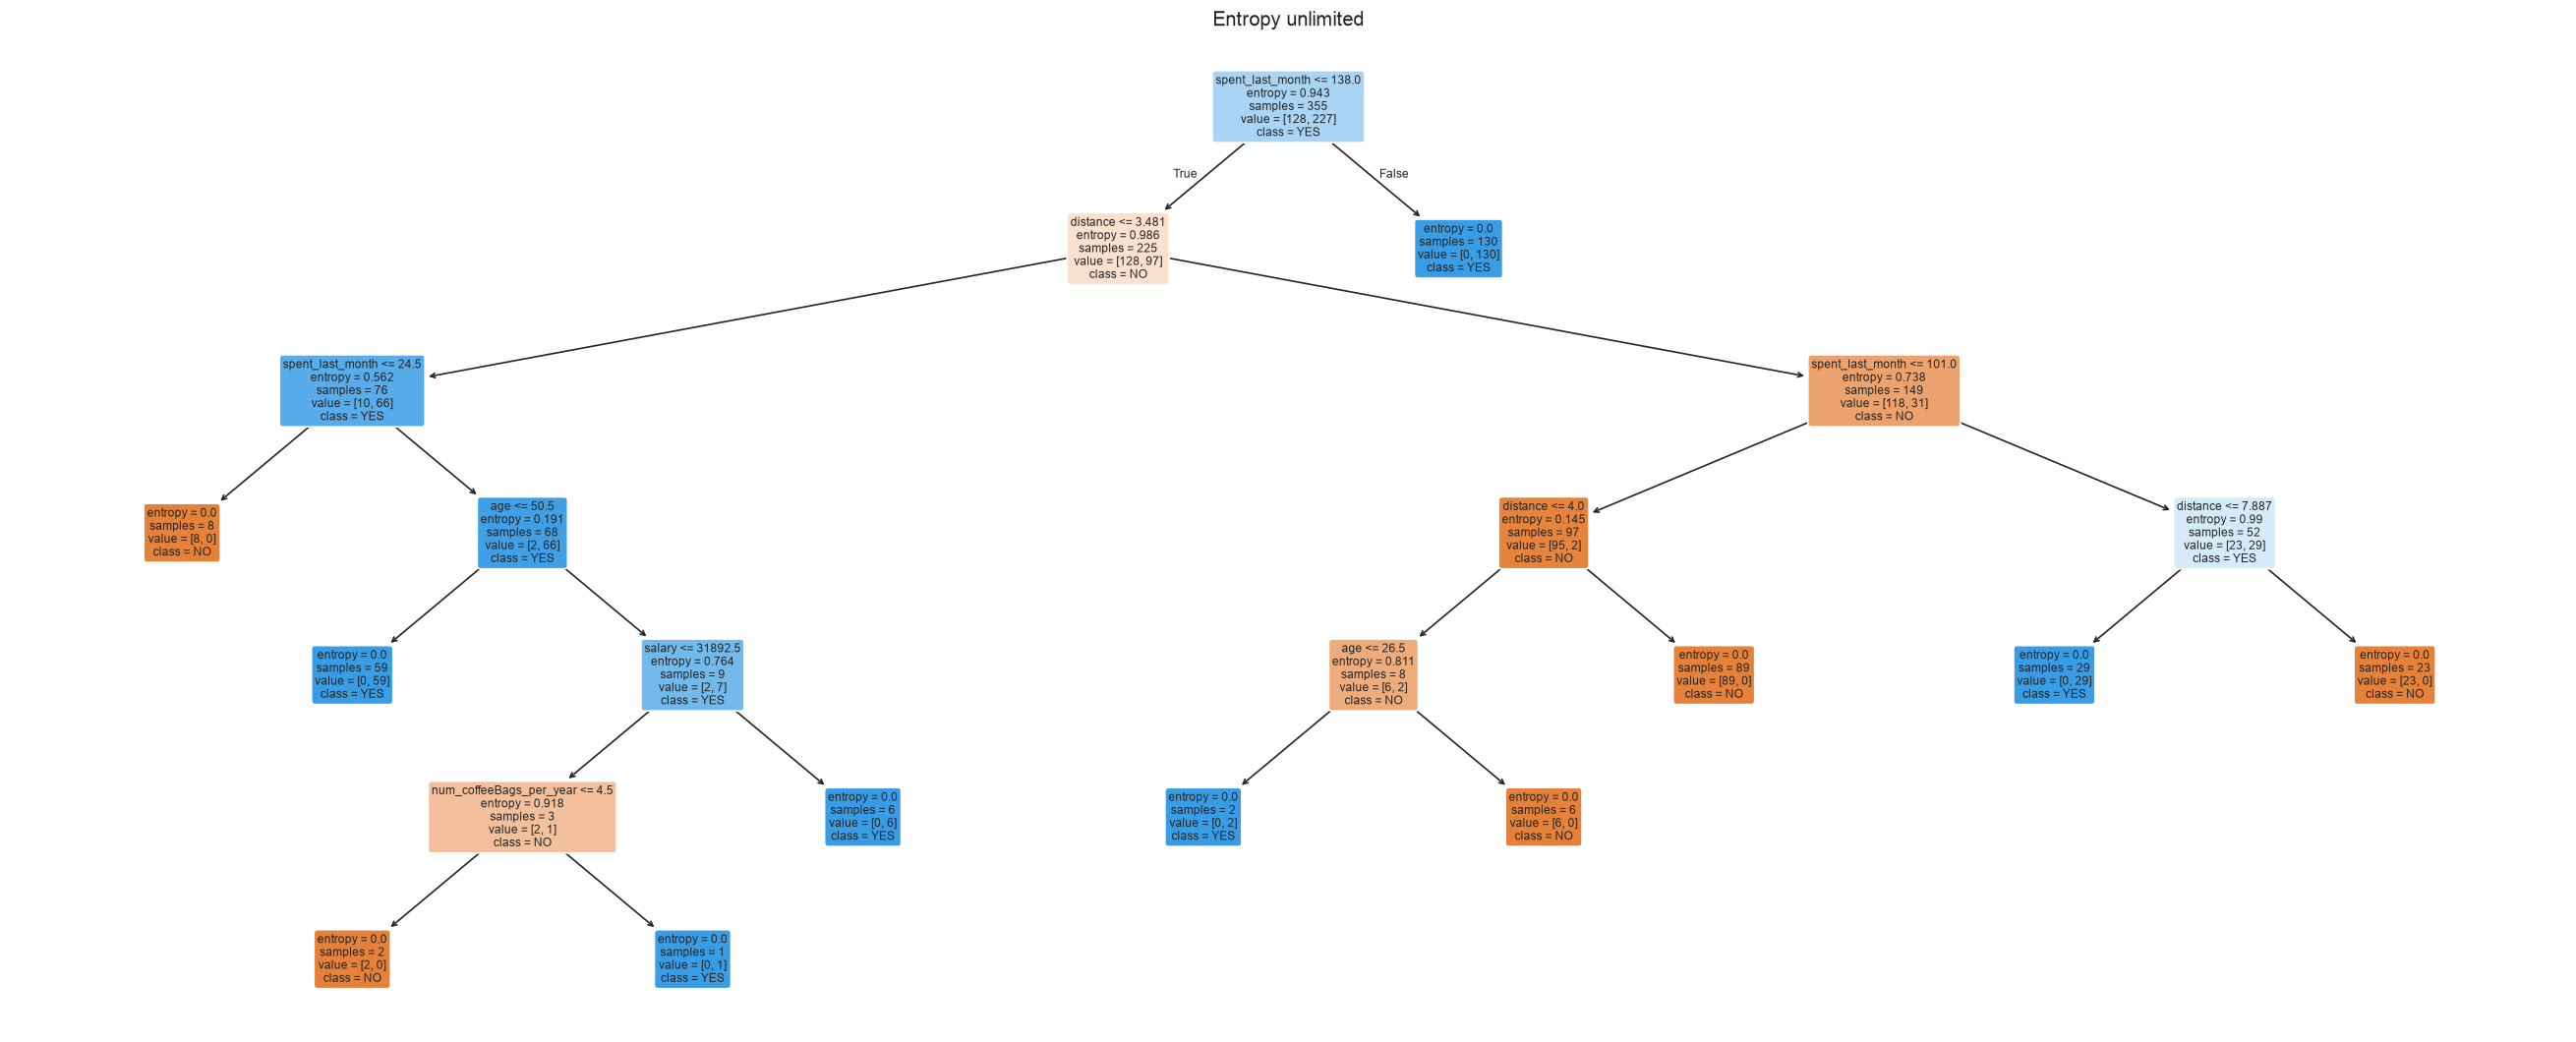

In [29]:
show_tree(entr_model, 'Entropy unlimited')

## Model 1: Entropy model - no max_depth: Interpretation and evaluation

In [30]:
evaluate('Entropy unlimited', entr_model)

model                Entropy unlimited
train_accuracy                     1.0
test_accuracy                      1.0
balanced_accuracy                  1.0
precision_yes                      1.0
recall_yes                         1.0
f1_yes                             1.0
roc_auc                            1.0
              precision    recall  f1-score   support

          NO     1.0000    1.0000    1.0000        43
         YES     1.0000    1.0000    1.0000        76

    accuracy                         1.0000       119
   macro avg     1.0000    1.0000    1.0000       119
weighted avg     1.0000    1.0000    1.0000       119

Confusion matrix: actual rows / predicted columns, NO then YES
[[43  0]
 [ 0 76]]


**Interpretation:** The unlimited entropy tree can fit very detailed rules. Compare training accuracy with test accuracy and training-fold cross-validation above; perfect training performance is not evidence of perfect generalization. The classification report shows both YES and NO recall, so an apparently good overall accuracy does not hide errors in one class.

**Computed results:** Unlimited entropy achieves 100% training and 100% test accuracy (119/119). Mean training-CV balanced accuracy is 97.84%, so the perfect result on this particular test split should not be generalized to future customers. The target is excluded from the eight predictors and missing-label rows are excluded from fitting.

## Model 2: Gini impurity model - no max_depth

Gini impurity, like entropy, is a measure of how well a given feature (and threshold) splits the data into categories.

Their equations are similar, but Gini impurity doesn't require logorathmic functions, which can be computationally expensive. 

In [31]:
gini_model = clone(tree_candidates['Gini unlimited'])
gini_model.fit(X_train, y_train)
y_pred = gini_model.predict(X_test)
print(pd.Series(y_pred).value_counts())
print('Depth:', gini_model.get_depth(), '| Leaves:', gini_model.get_n_leaves())

YES    75
NO     44
Name: count, dtype: int64
Depth: 4 | Leaves: 9


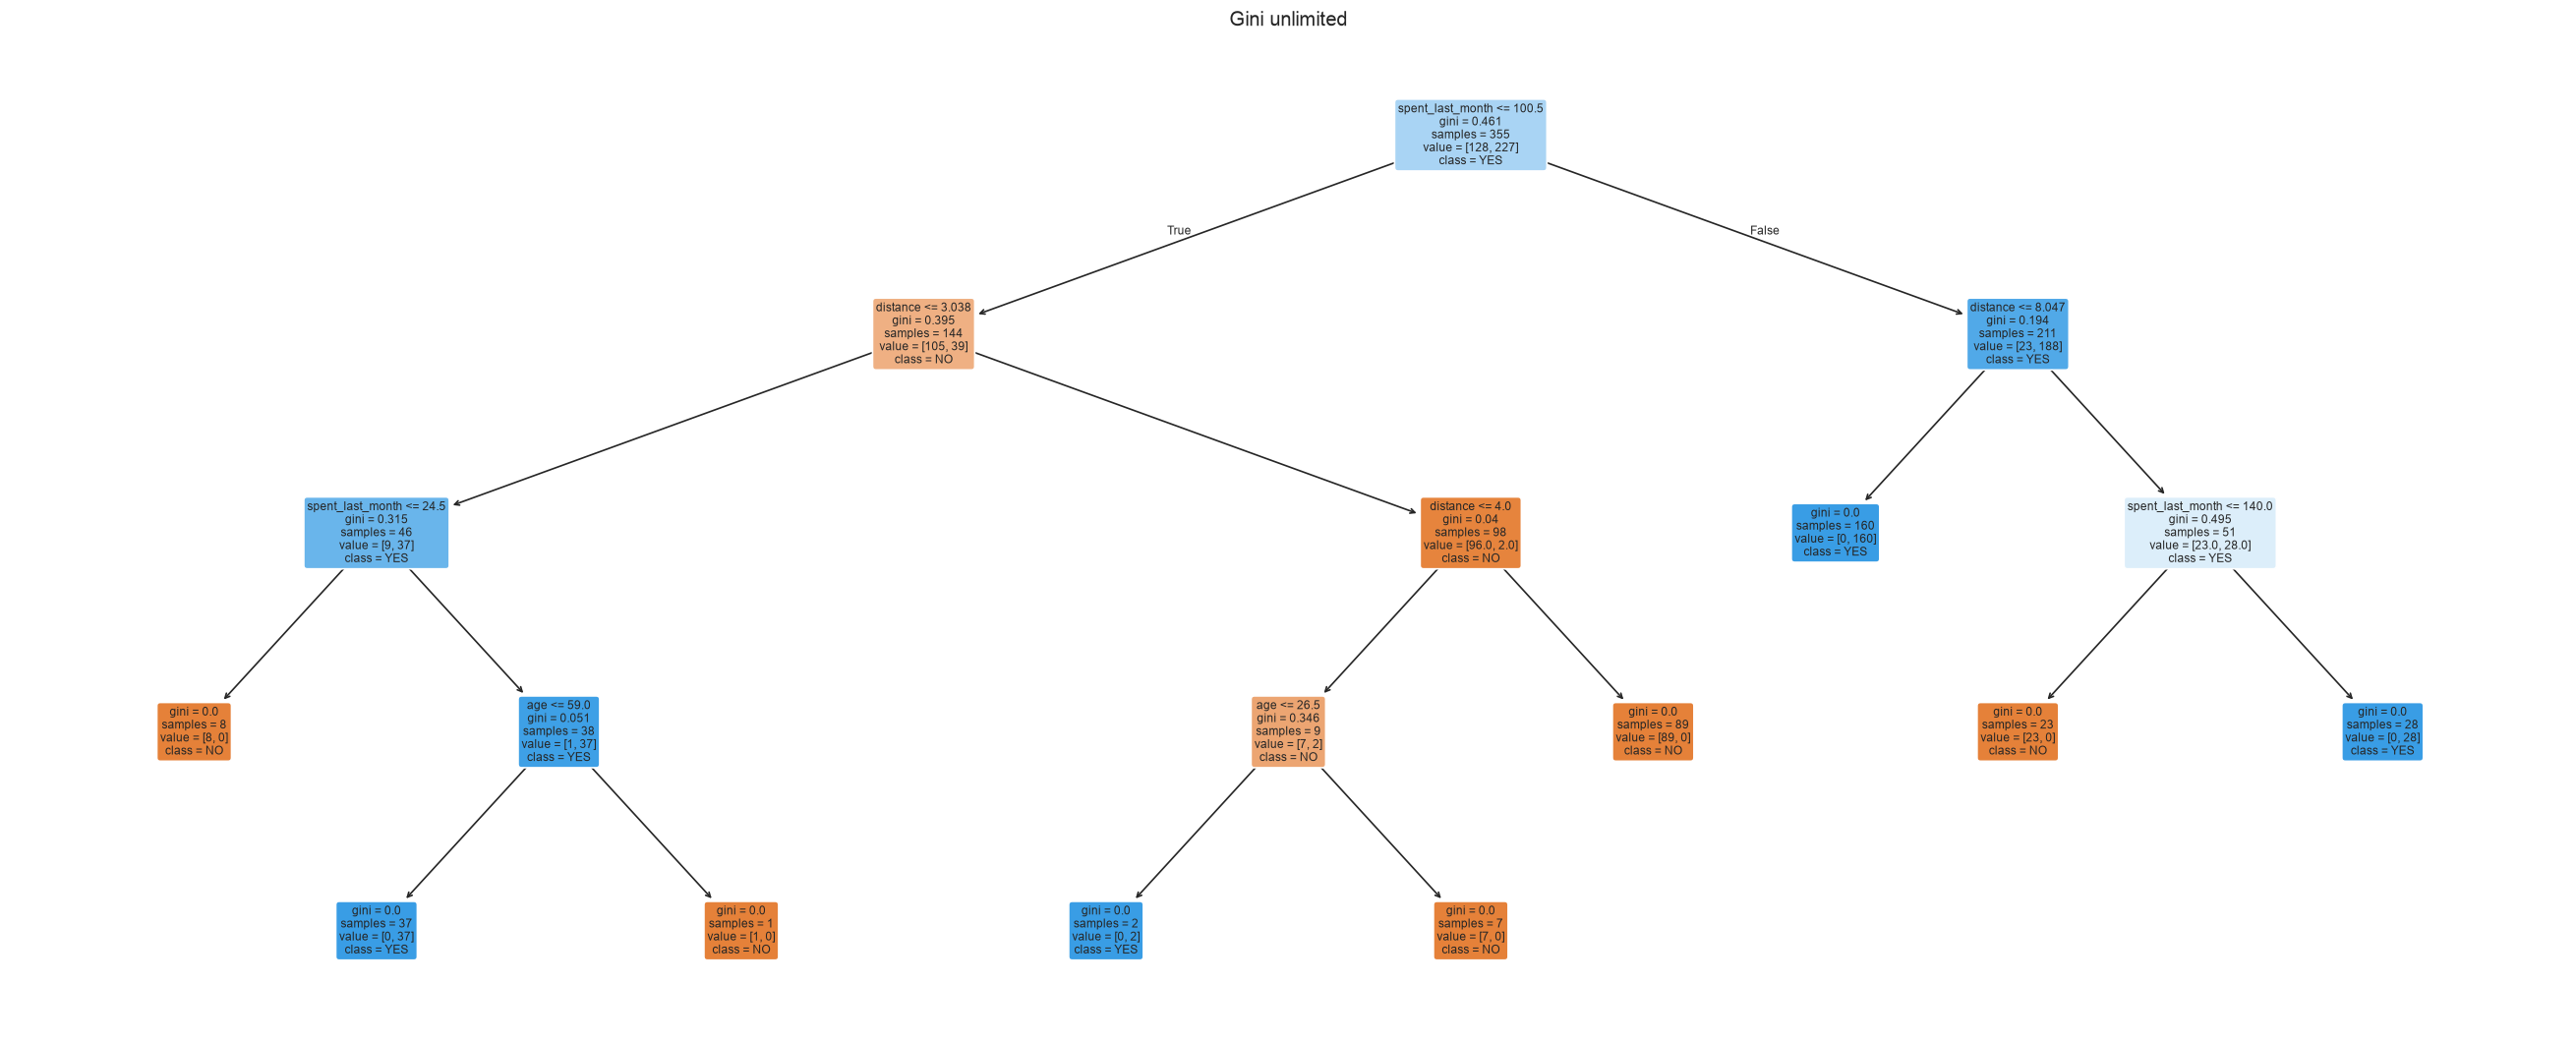

In [32]:
show_tree(gini_model, 'Gini unlimited')

In [33]:
evaluate('Gini unlimited', gini_model)

model                Gini unlimited
train_accuracy                  1.0
test_accuracy              0.991597
balanced_accuracy          0.993421
precision_yes                   1.0
recall_yes                 0.986842
f1_yes                     0.993377
roc_auc                    0.993421
              precision    recall  f1-score   support

          NO     0.9773    1.0000    0.9885        43
         YES     1.0000    0.9868    0.9934        76

    accuracy                         0.9916       119
   macro avg     0.9886    0.9934    0.9909       119
weighted avg     0.9918    0.9916    0.9916       119

Confusion matrix: actual rows / predicted columns, NO then YES
[[43  0]
 [ 1 75]]


**Comparison:** Both unlimited trees use the same observations, split and seed. Changing the impurity measure can change their splits and errors. The summary below quantifies the difference; neither criterion is universally superior. Training-only cross-validation, rather than the largest test score, selects the candidate used for demand estimation.

**Computed comparison:** Unlimited Gini scores 99.16% test accuracy (118/119), versus entropy at 100%. Its YES recall is 98.68%, with one YES classified as NO. Entropy also has the slightly higher mean CV balanced accuracy (97.84% vs 97.47%). The one-case test difference is small.

## Model 3: Entropy model - max depth 3
We're going to try to limit the depth of our decision tree, using entropy first.  

As you know, we need to strike a balance with tree depth. 

Insufficiently deep, and we're not giving the tree the opportunity to spot the right patterns in the training data.

Excessively deep, and we're probably going to make a tree that overfits to the training data, at the cost of very high error on the (hitherto unseen) test data. 

Sophisticated data scientists use methods like random search with cross-validation to systematically find a good depth for their tree. We'll start with picking 3, and see how that goes. 

In [34]:
entr_model2 = clone(tree_candidates['Entropy depth 3'])
entr_model2.fit(X_train, y_train)
y_pred = entr_model2.predict(X_test)
print(pd.Series(y_pred).value_counts())
print('Depth:', entr_model2.get_depth(), '| Leaves:', entr_model2.get_n_leaves())

YES    84
NO     35
Name: count, dtype: int64
Depth: 3 | Leaves: 5


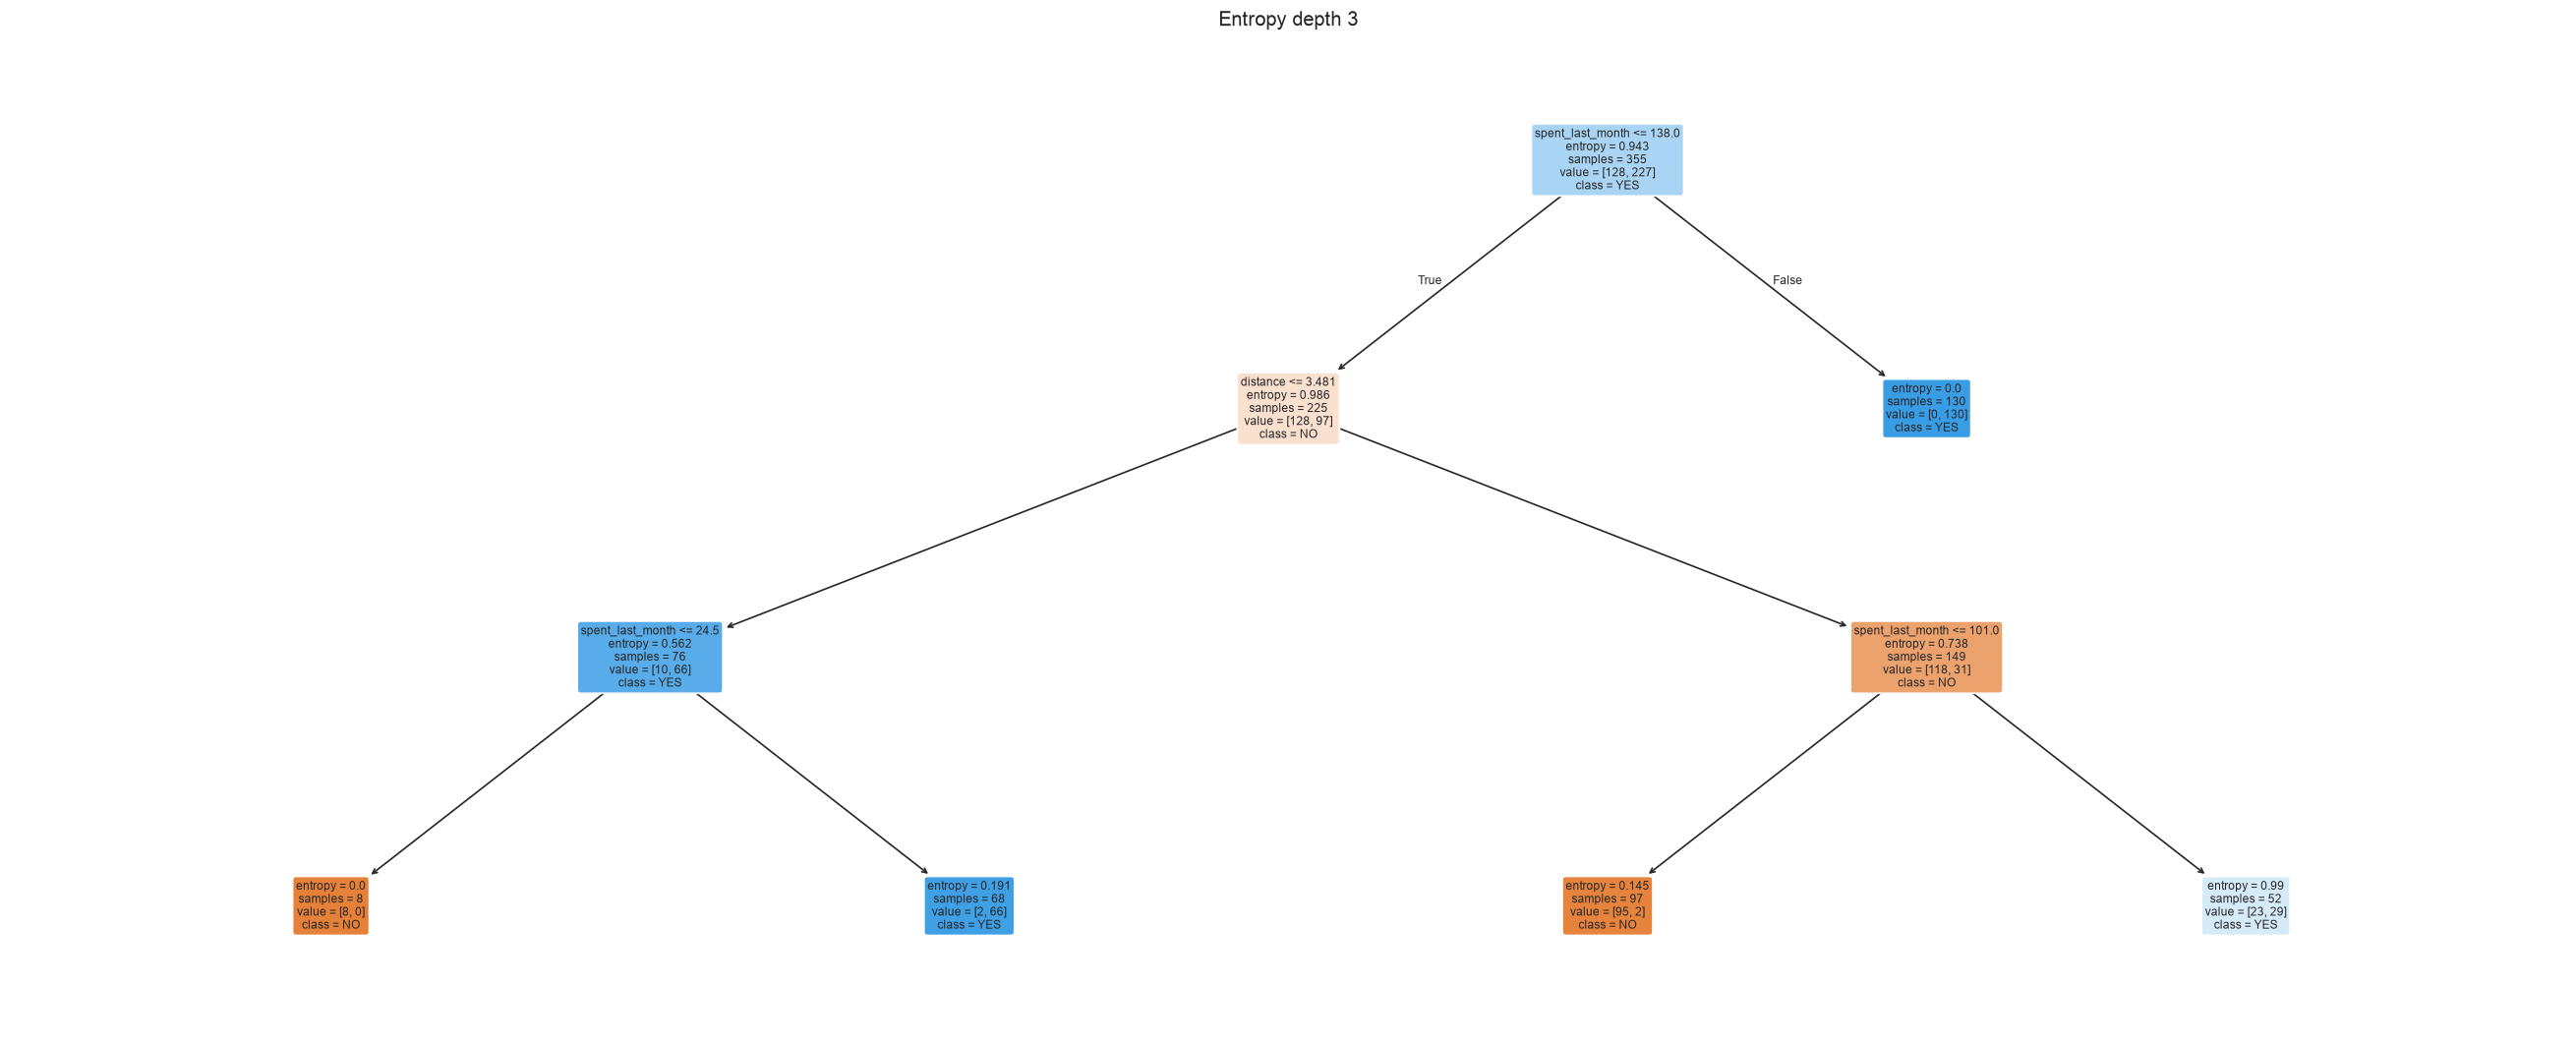

In [35]:
show_tree(entr_model2, 'Entropy depth 3')

In [36]:
evaluate('Entropy depth 3', entr_model2)

model                Entropy depth 3
train_accuracy              0.923944
test_accuracy               0.915966
balanced_accuracy            0.88877
precision_yes               0.892857
recall_yes                  0.986842
f1_yes                        0.9375
roc_auc                     0.975826
              precision    recall  f1-score   support

          NO     0.9714    0.7907    0.8718        43
         YES     0.8929    0.9868    0.9375        76

    accuracy                         0.9160       119
   macro avg     0.9321    0.8888    0.9046       119
weighted avg     0.9212    0.9160    0.9138       119

Confusion matrix: actual rows / predicted columns, NO then YES
[[34  9]
 [ 1 75]]


**Answer:** A shallower tree is not automatically inferior if its accuracy decreases on one split. Depth 3 limits complexity and often reduces variance, at the cost of additional bias. Check training/test gaps and cross-validation, as well as interpretability. Any claimed decrease must match the computed results; it is not assumed from the template.

**Computed results:** Depth-3 entropy scores 92.39% on training data and 91.60% on test data, with CV balanced accuracy 93.73%. Here depth 3 sacrifices too much predictive detail compared with unlimited entropy; the small training/test gap alone does not make it superior.

## Model 4: Gini impurity  model - max depth 3
We're now going to try the same with the Gini impurity model. 

In [37]:
gini_model2 = clone(tree_candidates['Gini depth 3'])
gini_model2.fit(X_train, y_train)
y_pred = gini_model2.predict(X_test)
print(pd.Series(y_pred).value_counts())
print('Depth:', gini_model2.get_depth(), '| Leaves:', gini_model2.get_n_leaves())

YES    74
NO     45
Name: count, dtype: int64
Depth: 3 | Leaves: 7


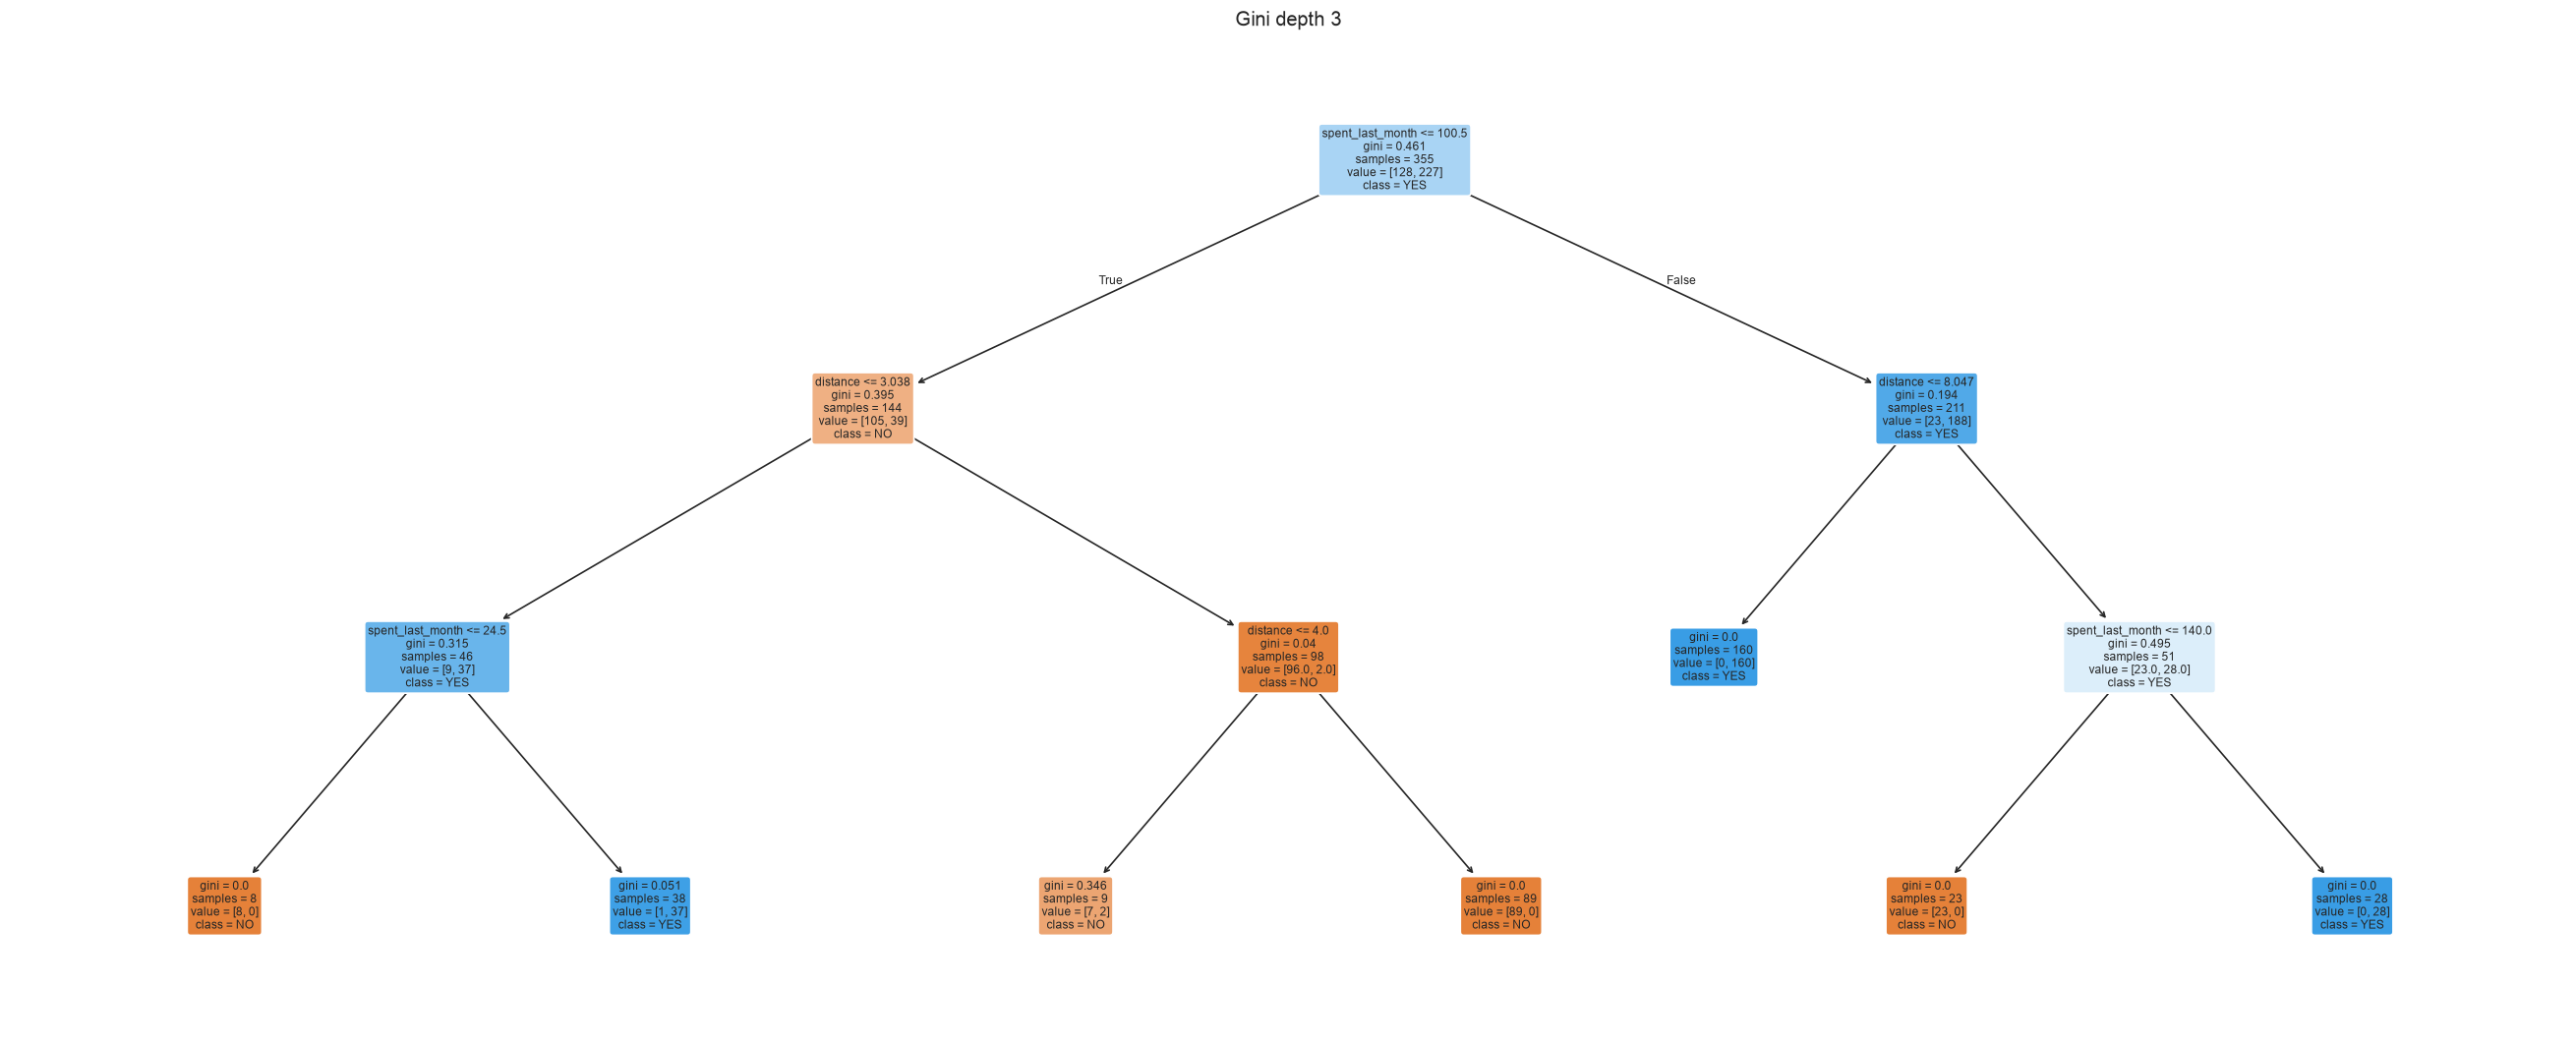

In [38]:
show_tree(gini_model2, 'Gini depth 3')

In [39]:
evaluate('Gini depth 3', gini_model2)

model                Gini depth 3
train_accuracy           0.991549
test_accuracy            0.983193
balanced_accuracy        0.986842
precision_yes                 1.0
recall_yes               0.973684
f1_yes                   0.986667
roc_auc                  0.993421
              precision    recall  f1-score   support

          NO     0.9556    1.0000    0.9773        43
         YES     1.0000    0.9737    0.9867        76

    accuracy                         0.9832       119
   macro avg     0.9778    0.9868    0.9820       119
weighted avg     0.9839    0.9832    0.9833       119

Confusion matrix: actual rows / predicted columns, NO then YES
[[43  0]
 [ 2 74]]


**Answer:** A depth-3 Gini tree offers a short, interpretable set of rules, but elegance alone does not make it the best predictor. We select the single tree by mean training-CV balanced accuracy, and report all held-out metrics for comparison. A shallower tree may be preferable when its performance is close and operational simplicity matters; here the selected name is printed explicitly.

**Computed results:** Depth-3 Gini scores 98.32% test accuracy and 97.63% mean CV balanced accuracy, close to unlimited entropy at 97.84% CV. This is a strong interpretable alternative, but the predeclared CV rule selects unlimited entropy. Calling this automatically the best tree, as the template suggests, would overstate the evidence.

# 4. Evaluating and concluding
## 4a. How many customers will buy Hidden Farm coffee? 
Let's first ascertain how many loyal customers claimed, in the survey, that they will purchase the Hidden Farm coffee. 

In [40]:
known_yes = int((coffeeData['Decision']=='YES').sum())
print(coffeeData['Decision'].value_counts(dropna=False))

Decision
YES    303
NaN    228
NO     171
Name: count, dtype: int64


Let's now determine the number of people that, according to the model, will be willing to buy the Hidden Farm coffee. 
1. First we subset the Prediction dataset into `new_X` considering all the variables except `Decision` 
2. Use that dataset to predict a new variable called `potential_buyers`

In [41]:
feature_cols = features.copy()
new_X = Prediction[feature_cols].copy()

In [42]:
# After evaluation, refit the CV-selected tree on all 474 labeled rows.
final_tree = Pipeline([('preprocess', clone(preprocessor)),
    ('model', clone(tree_candidates[selected_tree_name]))])
final_tree.fit(X, y)
potential_buyers = final_tree.predict(new_X)

In [43]:
np.unique(potential_buyers, return_counts=True)

(array(['NO', 'YES'], dtype=object), array([ 47, 181]))

**Compute the total from the actual file:** known YES responses + predicted YES among missing decisions. The template's fixed 303 + 183 example is not used. A customer is counted once; known survey labels are retained.

In [44]:
total_customers = len(coffeeData)
print('Customers in provided CSV:', total_customers)

Customers in provided CSV: 702


In [45]:
tree_unknown_yes = int((potential_buyers=='YES').sum())
tree_total_yes = known_yes + tree_unknown_yes
tree_buyer_share = tree_total_yes / total_customers

In [46]:
minimum_buyers = int(np.floor(0.70*total_customers)) + 1
print(f'{known_yes} known YES + {tree_unknown_yes} predicted YES = {tree_total_yes}/{total_customers} ({tree_buyer_share:.2%})')
print('Minimum buyers for strictly more than 70%:', minimum_buyers)
print('Tree decision:', 'GO' if tree_buyer_share>0.70 else 'NO-GO')

303 known YES + 181 predicted YES = 484/702 (68.95%)
Minimum buyers for strictly more than 70%: 492
Tree decision: NO-GO


## 4b. Decision

Apply the stated rule strictly: proceed only when estimated buyers / actual surveyed customers is **greater than 70%**. The result above is a model-based estimate of purchase intent, not confirmed demand. The target is binary and cannot tell us how many kilograms or units each customer will buy. Before committing, validate interest through preorders or a pilot and assess cost, margin, shipping and the consequences of unsold stock. The final comparison below checks whether the forest changes this conclusion.

**Decision: NO-GO under the stated rule.** The selected tree estimates 303 known YES + 181 predicted YES = **484/702 (68.95%)**. Strictly more than 70% requires at least **492 buyers**, or 189 of the 228 unknown respondents to say YES. The estimate is eight buyers short. Do not treat that small shortfall as certainty; a pilot or preorder campaign could resolve the uncertainty.

## 5. Random Forest

A random forest fits many trees using bootstrap samples and random feature subsets, then averages their class probabilities. This can reduce the variance of a single tree, but improvement is not guaranteed. Models are not all inherently stochastic; fixed seeds make this experiment reproducible. Tune the forest on training data only, with the same stratified folds and primary balanced-accuracy metric as the trees.

### 5a. Import necessary modules

In [47]:
# RandomForestClassifier and GridSearchCV were imported in the first cell.

### 5b. Model
You'll use your X_train and y_train variables just as before.

You'll then need to make a variable (call it firstRFModel) to store your new Random Forest model. You'll assign this variable the result of calling RandomForestClassifier().

Then, just as before, you'll call fit() on that firstRFModel variable, and plug in X_train and y_train.

Finally, you should make a variable called y_pred, and assign it the result of calling the predict() method on your new firstRFModel, with the X_test data passed to it. 

Forest parameters: {'model__max_depth': 5, 'model__min_samples_leaf': 1}
Forest mean CV balanced accuracy: 0.9585470085470085
                                                  params  mean_test_score  std_test_score
   {'model__max_depth': 3, 'model__min_samples_leaf': 1}         0.901054        0.028867
   {'model__max_depth': 3, 'model__min_samples_leaf': 5}         0.904900        0.032232
   {'model__max_depth': 5, 'model__min_samples_leaf': 1}         0.958547        0.026253
   {'model__max_depth': 5, 'model__min_samples_leaf': 5}         0.944285        0.028615
{'model__max_depth': None, 'model__min_samples_leaf': 1}         0.958547        0.026253
{'model__max_depth': None, 'model__min_samples_leaf': 5}         0.948131        0.034039
model                Random forest
train_accuracy            0.997183
test_accuracy             0.966387
balanced_accuracy         0.968635
precision_yes             0.986486
recall_yes                0.960526
f1_yes                    0.973333

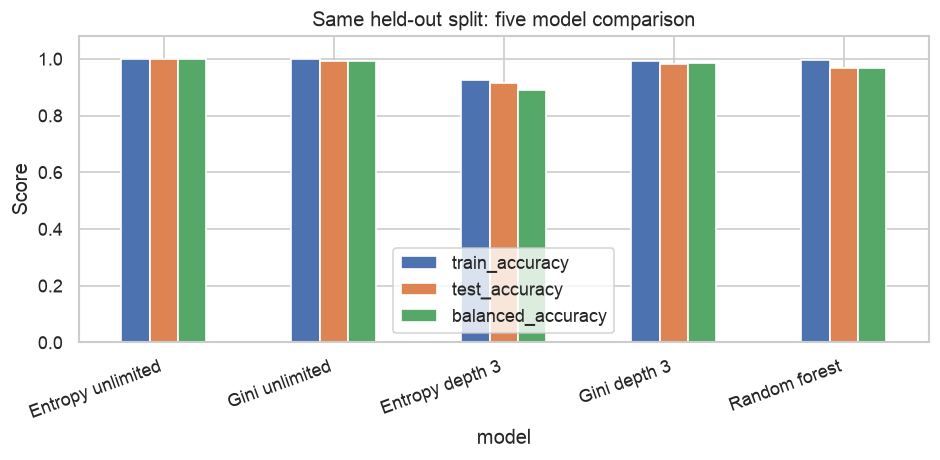

Forest: 303 known + 183 predicted = 486/702 (69.23%)
Forest decision: NO-GO
Overall model selected using CV: Entropy unlimited
Overall business rule: NO-GO
Model sensitivity after refitting on all known decisions:
            model  predicted_unknown_yes  total_yes    share
Entropy unlimited                    181        484 0.689459
   Gini unlimited                    177        480 0.683761
  Entropy depth 3                    183        486 0.692308
     Gini depth 3                    177        480 0.683761
    Random forest                    183        486 0.692308
Probability-sum estimate: 484.00 buyers (68.95%)
Unknown YES needed to exceed the rule: 189 of 228
Logical bounds without modeling: 0.43162393162393164 0.7564102564102564


In [48]:
rf_pipeline = Pipeline([('preprocess', clone(preprocessor)),
    ('model', RandomForestClassifier(n_estimators=200, random_state=1234, n_jobs=1))])
rf_search = GridSearchCV(rf_pipeline,
    {'model__max_depth':[3,5,None], 'model__min_samples_leaf':[1,5]},
    cv=cv, scoring='balanced_accuracy', n_jobs=1, refit=True)
rf_search.fit(X_train_raw, y_train)
print('Forest parameters:', rf_search.best_params_)
print('Forest mean CV balanced accuracy:', rf_search.best_score_)
print(pd.DataFrame(rf_search.cv_results_)[['params','mean_test_score','std_test_score']].to_string(index=False))
firstRFModel = rf_search.best_estimator_.named_steps['model']
# Same training data produces the same encoder feature order.
assert np.allclose(rf_search.best_estimator_.named_steps['preprocess'].transform(X_test_raw), X_test)
evaluate('Random forest', firstRFModel)
model_comparison = pd.DataFrame(evaluation_rows).set_index('model')
print(model_comparison.round(4))
fig, ax = plt.subplots(figsize=(8,4))
model_comparison[['train_accuracy','test_accuracy','balanced_accuracy']].plot.bar(ax=ax)
ax.set(ylim=(0,1.08),ylabel='Score',title='Same held-out split: five model comparison')
plt.xticks(rotation=20,ha='right');plt.tight_layout();plt.show()

final_rf = clone(rf_search.best_estimator_).fit(X,y)
rf_unknown = final_rf.predict(new_X)
rf_unknown_yes = int((rf_unknown=='YES').sum())
rf_total_yes = known_yes + rf_unknown_yes
rf_buyer_share = rf_total_yes/total_customers
print(f'Forest: {known_yes} known + {rf_unknown_yes} predicted = {rf_total_yes}/{total_customers} ({rf_buyer_share:.2%})')
print('Forest decision:', 'GO' if rf_buyer_share>0.70 else 'NO-GO')

# Choose the overall model using training CV, never the buyer percentage or test score.
forest_wins = rf_search.best_score_ > cv_table.loc[selected_tree_name,'cv_balanced_accuracy']
selected_name = 'Random forest' if forest_wins else selected_tree_name
selected_final = final_rf if forest_wins else final_tree
selected_share = rf_buyer_share if forest_wins else tree_buyer_share
print('Overall model selected using CV:', selected_name)
print('Overall business rule:', 'GO' if selected_share>0.70 else 'NO-GO')

sensitivity = []
for name, est in tree_candidates.items():
    fitted = Pipeline([('preprocess',clone(preprocessor)),('model',clone(est))]).fit(X,y)
    count = int((fitted.predict(new_X)=='YES').sum())
    sensitivity.append({'model':name,'predicted_unknown_yes':count,
                        'total_yes':known_yes+count,'share':(known_yes+count)/total_customers})
sensitivity.append({'model':'Random forest','predicted_unknown_yes':rf_unknown_yes,
                    'total_yes':rf_total_yes,'share':rf_buyer_share})
sensitivity = pd.DataFrame(sensitivity)
print('Model sensitivity after refitting on all known decisions:')
print(sensitivity.to_string(index=False))

# Probability sum is a supplementary estimate, not a calibrated confidence interval.
yes_index = list(selected_final.classes_).index('YES')
probabilities = selected_final.predict_proba(new_X)[:,yes_index]
probability_total = known_yes + probabilities.sum()
print(f'Probability-sum estimate: {probability_total:.2f} buyers ({probability_total/total_customers:.2%})')
print('Unknown YES needed to exceed the rule:', minimum_buyers-known_yes, 'of',len(new_X))
print('Logical bounds without modeling:', known_yes/total_customers, (known_yes+len(new_X))/total_customers)
predictions = pd.DataFrame({'source_csv_row':new_X.index+2,
    'predicted_decision':selected_final.predict(new_X),'probability_yes':probabilities})
# Source row includes the CSV header; it is not an actual customer ID.
predictions.to_csv('Hidden_Farm_Predictions.csv',index=False)
model_comparison.to_csv('Model_Comparison.csv')

### 5c. Revised conclusion

The results above compare the selected tree and forest using the same split. A forest may improve some metrics and worsen others, so improvement is checked rather than assumed. Model choice is locked by training-only cross-validation. After evaluation, refitting on all known decisions uses the available labels for the 228 missing-decision predictions; this refit is not assigned a new test score.

**Limitations:** Survey intent is not a purchase. Missing responses may be systematically different from respondents, and loyal customers may not represent future customers. The 70% rule is a scenario assumption, not a profitability analysis. Hard-label counts depend on the classifier threshold; probability sums are only supplementary because these probabilities were not calibrated. The range across models is a sensitivity check, not a statistical confidence interval. Do not choose whichever model happens to cross 70%.

**Revised conclusion: unchanged—NO-GO under the rule.** The tuned forest uses 200 trees, max_depth=5 and min_samples_leaf=1. Its mean CV balanced accuracy is **95.85%**, below the selected tree’s **97.84%**. Its test accuracy is **96.64%**, so the forest does not improve predictive accuracy in this run. It estimates **486/702 buyers (69.23%)**, six short of the minimum 492. Across all five models, estimated intent ranges from **68.38% to 69.23%**, all below the cutoff. The selected single tree remains the primary estimate. These percentages concern purchase intent, not units or revenue.

### Concepts and references
Entropy: $H=-\sum_k p_k\log_2(p_k)$. Gini impurity: $G=1-\sum_k p_k^2$. Both are zero for a pure node. A split is chosen to reduce weighted child impurity. scikit-learn uses a CART-style binary tree; selecting entropy does not turn it into the original ID3 algorithm. Depth limits reduce complexity, while forests average across varied trees to reduce variance.

Original assignment and data: supplied Springboard RR Diner Coffee case study. Solution code and explanations prepared with ChatGPT assistance. Review and understand the work before submission.

API reference: [scikit-learn Decision Trees](https://scikit-learn.org/stable/modules/tree.html).